,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29 00:00:00,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15 00:00:00,pet_shop
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05 00:00:00,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20 00:00:00,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17 00:00:00,garden_tools


--- 园林工具物流专项分析 (已剔除空值) ---
1. 全年平均配送天数: 13.20 天
2. 全年平均延迟率: 8.03%
3. 11 月(黑五期间)延迟率: 14.59%


<Axes: title={'center': 'Monthly Late Rate Trend'}, xlabel='month'>

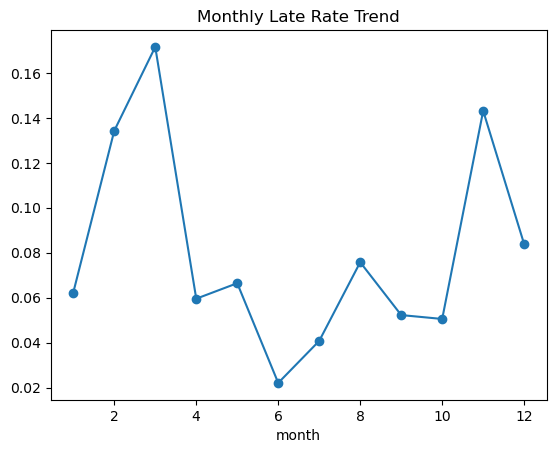

In [2]:
# ==========================================
import pandas as pd

# Se parte de las tablas base ya cargadas en pandas:
# - orders        (order_id, customer_id, ...)
# - order_items   (order_id, seller_id, ...)
# - customers     (customer_id, customer_state, ...)
# - sellers       (seller_id, seller_state, ...)
# 读取数据 
products = pd.read_csv('olist_products_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
product_category_name_translation = pd.read_csv('product_category_name_translation.csv')
# 步骤 1：数据集成与品类名翻译
# ==========================================
# 假设 product_category_name_translation 是翻译表
# 先将葡萄牙语分类名翻译成英语，方便我们搜索 'garden_tools'
products=products.merge(product_category_name_translation, on='product_category_name', how='left')
# 将订单明细与产品英语分类名合并,内连接只保留有英文分类的订单相关信息
df_items_full = order_items.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='inner')

# 将品类信息合入你之前做好的订单聚合表 
df_final = (
    orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']]
        # 1. 关联商品和品类翻译（确保 df_items_full 已经包含了英语品类名）
        .merge(df_items_full[['order_id', 'product_category_name_english']], on='order_id', how='inner')
        
        # 2. 链式聚合：按订单分组，处理每个订单的指标
        .groupby('order_id').agg({
            'order_purchase_timestamp': 'first',
            'order_delivered_customer_date': 'first',
            'order_estimated_delivery_date': 'first',
            'product_category_name_english': 'first' # 假设一单属于一个主要品类
        })
        .reset_index()
)

display(df_final.head())
# ==========================================
# ==========================================
# 步骤 2：清洗数据并计算指标（修正版）
# ==========================================

# 1. 剔除送达日期为空的订单，避免无效比较
df_delivered = df_final.dropna(subset=['order_delivered_customer_date']).copy()

# 2. 转换日期格式
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df_delivered[col] = pd.to_datetime(df_delivered[col])

# 3. 计算配送天数
df_delivered['delivery_days'] = (df_delivered['order_delivered_customer_date'] - df_delivered['order_purchase_timestamp']).dt.days

# 4. 计算是否延迟 (业务定义：实际 > 预计)
# 这样比较就不会有红色警告了，因为我们已经删除了空值
df_delivered['is_late'] = (df_delivered['order_delivered_customer_date'] > df_delivered['order_estimated_delivery_date']).astype(int)

# 5. 提取月份
df_delivered['month'] = df_delivered['order_purchase_timestamp'].dt.month

# ==========================================
# 步骤 3：针对“园林工具”的精准分析
# ==========================================
garden_tools = df_delivered[df_delivered['product_category_name_english'] == 'garden_tools'].copy()

# 计算指标
if not garden_tools.empty:
    avg_delivery = garden_tools['delivery_days'].mean()
    annual_late_rate = garden_tools['is_late'].mean()
    
    # 11月数据切片
    nov_data = garden_tools[garden_tools['month'] == 11]
    nov_late_rate = nov_data['is_late'].mean() if not nov_data.empty else 0
    
    print(f"--- 园林工具物流专项分析 (已剔除空值) ---")
    print(f"1. 全年平均配送天数: {avg_delivery:.2f} 天")
    print(f"2. 全年平均延迟率: {annual_late_rate*100:.2f}%")
    print(f"3. 11 月(黑五期间)延迟率: {nov_late_rate*100:.2f}%")
    # 快速画出每月延迟率趋势图
df_delivered.groupby('month')['is_late'].mean().plot(kind='line', marker='o', title='Monthly Late Rate Trend')